In [1]:
# Необходимо для корректной работы внешних .py файлов
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, MinMaxScaler, TargetEncoder
from sklearn.model_selection import KFold
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import OneHotEncoder
from helper import *
from plots import *
import random

In [3]:
# фиксируем состояние генератора псевдослучайных чисел. Это необходимо, чтобы результаты модели не менялись с каждым новым запуском 
SEED = 42 # можно указать любое число
np.random.seed(SEED)
random.seed(SEED)

## 1. Предобработка

In [4]:
df = pd.read_csv('diamonds.csv')

In [5]:
# Общие преобразования
df_preprocessed = df.copy()

In [6]:
df_preprocessed = df_preprocessed.drop(columns=['Unnamed: 0'])

In [7]:
# удалим строки с нулевыми значениями x,y или z
df_preprocessed = df_preprocessed.query("~(x == 0) & ~(y == 0) & ~(z == 0)")

In [8]:
# делим данные на признаки и таргет
X, y = divide_data(df_preprocessed, 'price')

In [9]:
categorical_cols = ['cut', 'color', 'clarity']
numeric_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']

In [10]:
# Создаем предобработчик данных в виде последовательного Pipeline
preprocessor = Pipeline([
    ('transformations', ColumnTransformer(
        [('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)],
        remainder='passthrough',  # числовые колонки передаются без изменений
        verbose_feature_names_out=False
    ))
])

# Устанавливаем вывод в формате pandas DataFrame (для sklearn версии 1.0 и выше)
preprocessor.set_output(transform="pandas")

Pipeline(steps=[('transformations',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['cut', 'color', 'clarity'])],
                                   verbose_feature_names_out=False))])

In [11]:
# сохраним все бейслайн модели в виде списка для удобства
models = [
    ('SGDRegression', SGDRegressor(random_state=SEED, max_iter=1000)),
    ('DecisionTreeRegressor', DecisionTreeRegressor(random_state=SEED, max_depth=8)),
    ('RandomForestRegressor', RandomForestRegressor(random_state=SEED)),
    ('LGBMRegressor', LGBMRegressor(random_state=SEED))
]

In [12]:
# используем 5-блочную кросс-валидацию
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1295
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 26
[LightGBM] [Info] Start training from score 3926.531459
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000817 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1296
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 26
[LightGBM] [Info] Start training from score 3944.897997
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[Light

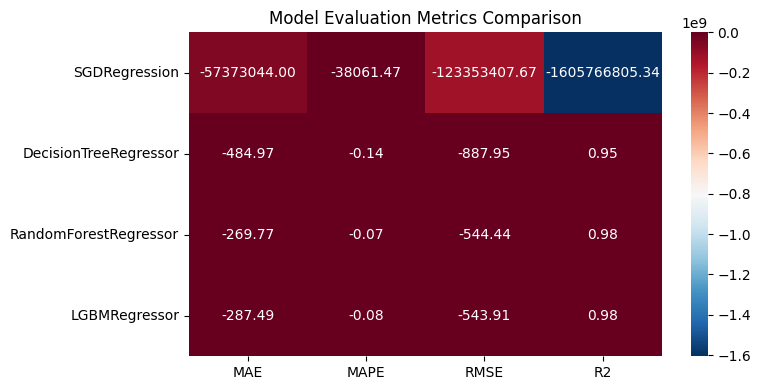

In [13]:
initial_metrics = train_evaluate_models_cv_reg(
    models=models,
    X=X,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

## 2. Преобразования данных и feature engineering

### 2.1 Применение StandardScaler (стандартизация)

#### 2.1.1 Без удаления

In [14]:
X_standard_scaler = X.copy()

In [15]:
scaled_columns = ['caratScaled', 'depthScaled', 'tableScaled','xScaled','yScaled','zScaled']
X_standard_scaler[scaled_columns] = X_standard_scaler[['carat', 'depth', 'table', 'x', 'y', 'z']]

In [16]:
preprocessor_standard_scaler = clone(preprocessor)

preprocessor_standard_scaler['transformations'].transformers.append(
    ('scaler', StandardScaler(), scaled_columns)
)


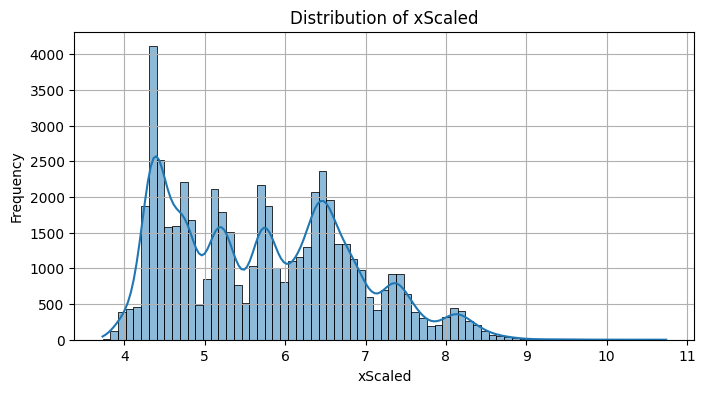

In [17]:
plot_hist_numeric(X_standard_scaler, 'xScaled')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001224 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2559
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 32
[LightGBM] [Info] Start training from score 3926.531459
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001147 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2557
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 32
[LightGBM] [Info] Start training from score 3944.897997
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead

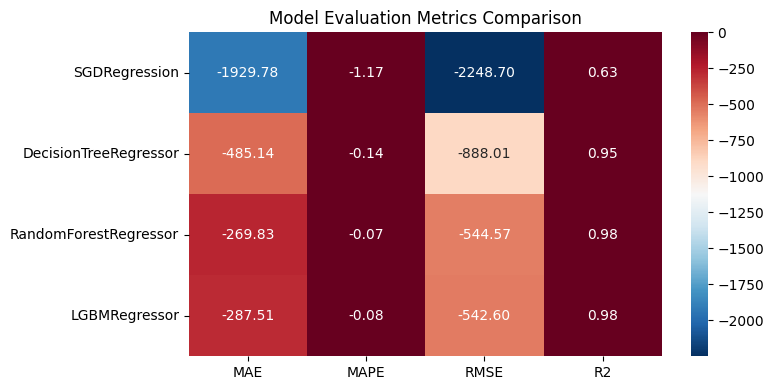

In [18]:
standard_scaler_metrics = train_evaluate_models_cv_reg(
    models=models,
    X=X_standard_scaler,
    y=y,
    preprocessor=preprocessor_standard_scaler,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                                 MAE          MAPE          RMSE            R2
 SGDRegression          5.737111e+07  38060.299281  1.233512e+08  1.605767e+09
 DecisionTreeRegressor -1.679366e-01     -0.000032 -6.749357e-02 -7.829279e-06
 RandomForestRegressor -6.154884e-02     -0.000041 -1.269980e-01 -8.852527e-06
 LGBMRegressor         -1.944941e-02     -0.000414  1.314406e+00  9.077331e-05)

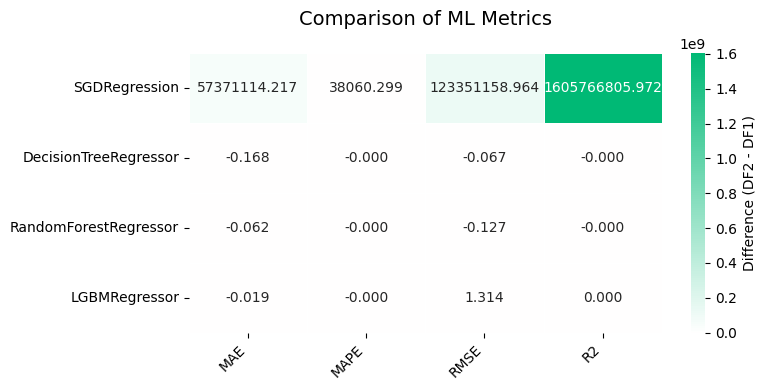

In [19]:
compare_metrics_heatmap(initial_metrics, standard_scaler_metrics)

Сильно улучшилась линейная регрессия, что ожидаемо, так как она плохо работает с сырыми данными. Остальные модели без изменений. 

#### 2.1.2 С удалением

In [20]:
X_standard_scaler_del = X.copy()

In [21]:
preprocessor_standard_scaler_del = clone(preprocessor)

preprocessor_standard_scaler_del['transformations'].transformers.append(
    ('scaler', StandardScaler(), ['carat', 'depth', 'table', 'x', 'y', 'z'])
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000798 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1304
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 26
[LightGBM] [Info] Start training from score 3926.531459
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000839 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1301
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 26
[LightGBM] [Info] Start training from score 3944.897997
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead

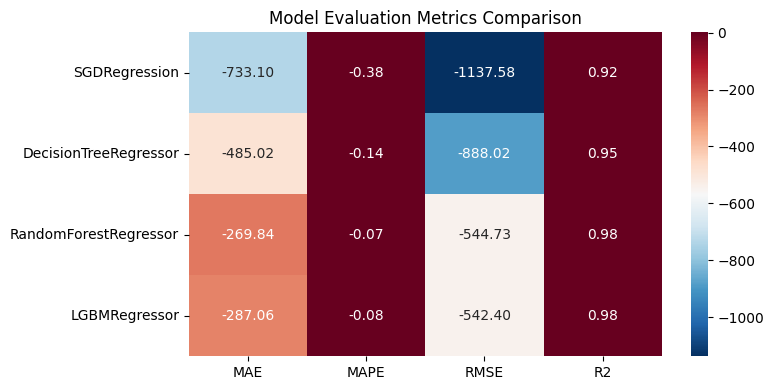

In [22]:
standard_scaler_metrics_del = train_evaluate_models_cv_reg(
    models=models,
    X=X_standard_scaler_del,
    y=y,
    preprocessor=preprocessor_standard_scaler_del,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                                 MAE          MAPE          RMSE            R2
 SGDRegression          5.737231e+07  38061.081396  1.233523e+08  1.605767e+09
 DecisionTreeRegressor -5.765640e-02     -0.000012 -7.093570e-02 -8.043348e-06
 RandomForestRegressor -7.815493e-02     -0.000003 -2.919442e-01 -2.057727e-05
 LGBMRegressor          4.303636e-01      0.000113  1.515428e+00  1.021608e-04)

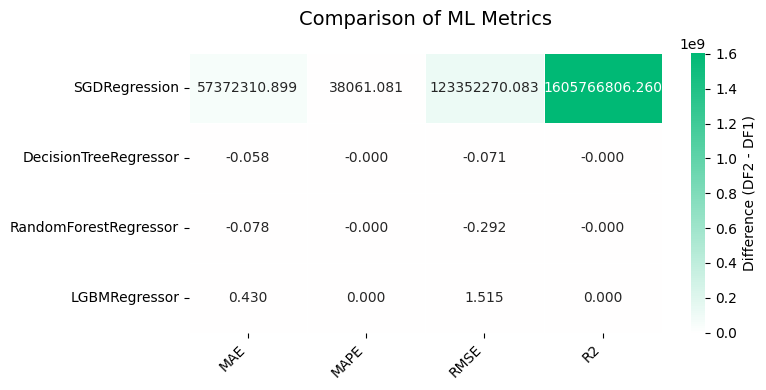

In [23]:
compare_metrics_heatmap(initial_metrics, standard_scaler_metrics_del)

С удалением результаты линейной регрессии стали еще лучше

### 2.2 Нормализация

#### 2.6.1 Без удаления

In [24]:
X_normalised = X.copy()

In [25]:
scaled_columns = ['caratScaled', 'depthScaled', 'tableScaled','xScaled','yScaled','zScaled']
X_normalised[scaled_columns] = X_normalised[['carat', 'depth', 'table', 'x', 'y', 'z']]

In [26]:
preprocessor_normalisation = clone(preprocessor)

preprocessor_normalisation['transformations'].transformers.append(
    ('scaler', MinMaxScaler(), scaled_columns)
)

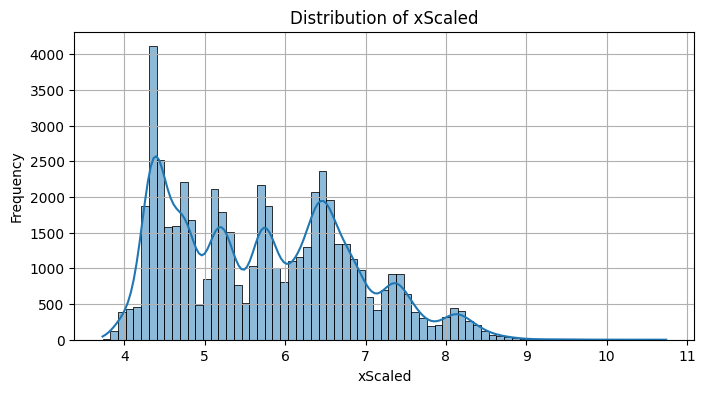

In [27]:
plot_hist_numeric(X_normalised, 'xScaled')

c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before converg

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000180 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2548
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 32
[LightGBM] [Info] Start training from score 3926.531459
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001028 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2551
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 32
[LightGBM] [Info] Start training from score 3944.897997
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[Light

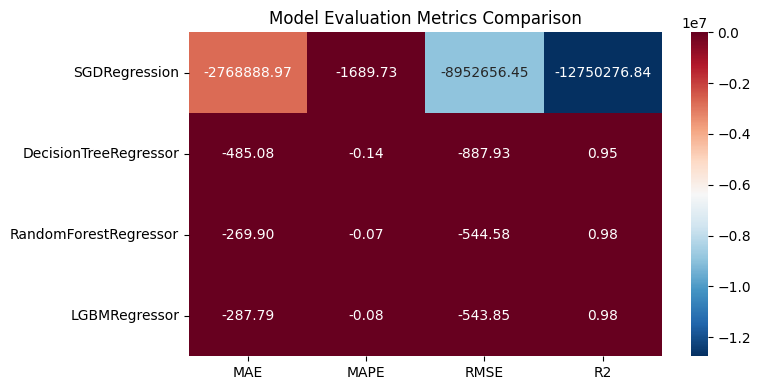

In [28]:
normalised_metrics = train_evaluate_models_cv_reg(
    models=models,
    X=X_normalised,
    y=y,
    preprocessor=preprocessor_normalisation,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                                 MAE          MAPE          RMSE            R2
 SGDRegression          5.460416e+07  36371.734462  1.144008e+08  1.593017e+09
 DecisionTreeRegressor -1.143486e-01     -0.000021  1.721732e-02  1.713826e-06
 RandomForestRegressor -1.321226e-01     -0.000055 -1.372865e-01 -9.274575e-06
 LGBMRegressor         -2.933392e-01     -0.000186  6.370245e-02  4.539965e-06)

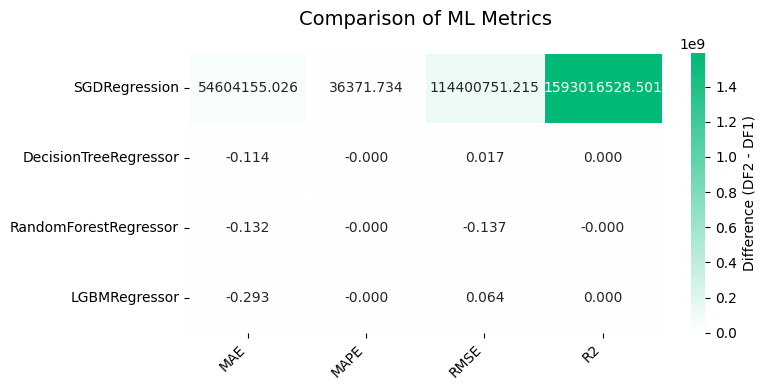

In [29]:
compare_metrics_heatmap(initial_metrics, normalised_metrics)

Регрессия лучше, но все равно плохо.

#### 2.2.2 С удалением

In [30]:
X_normalised_del = X.copy()

In [31]:
preprocessor_normalisation_del = clone(preprocessor)

preprocessor_normalisation_del['transformations'].transformers.append(
    ('scaler', MinMaxScaler(), ['carat', 'depth', 'table', 'x', 'y', 'z'])
)

c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000184 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1293
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 26
[LightGBM] [Info] Start training from score 3926.531459
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000203 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1295
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 26
[LightGBM] [Info] Start training from score 3944.897997
[LightGBM] [Warning] F

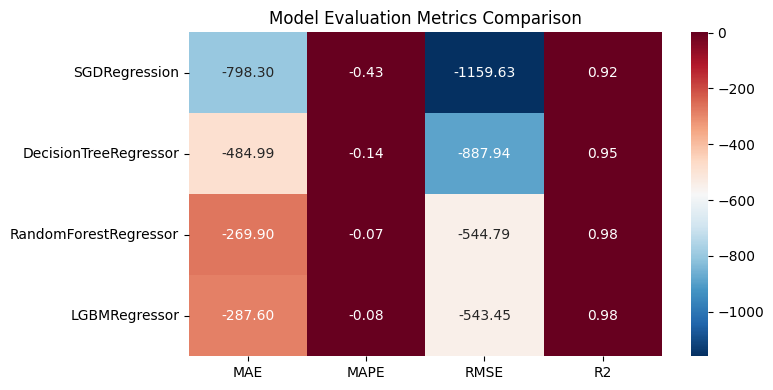

In [32]:
normalised_metrics_del = train_evaluate_models_cv_reg(
    models=models,
    X=X_normalised_del,
    y=y,
    preprocessor=preprocessor_normalisation_del,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                                 MAE          MAPE          RMSE            R2
 SGDRegression          5.737225e+07  38061.034082  1.233522e+08  1.605767e+09
 DecisionTreeRegressor -2.226996e-02     -0.000008  3.675224e-03  3.724089e-07
 RandomForestRegressor -1.292821e-01     -0.000019 -3.516030e-01 -2.399517e-05
 LGBMRegressor         -1.096387e-01     -0.000290  4.645855e-01  3.187829e-05)

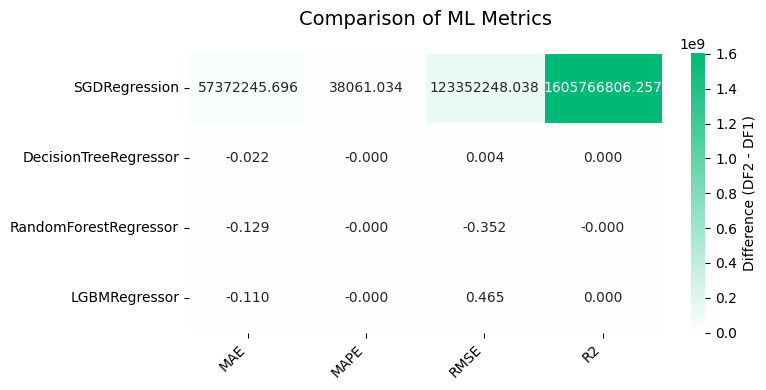

In [33]:
compare_metrics_heatmap(initial_metrics, normalised_metrics_del)

Регрессия сильно улучшилась

### 2.3 Создание новых признаков "xy","xz","yz"

Так как depth линейно зависит от x,y,z , попробуем преобразовать их в другие признаки.  

In [34]:
X_fich = X.copy()

In [35]:
X_fich['xy'] = X_fich['x']/X_fich['y']
X_fich['xz'] = X_fich['x']/X_fich['z']
X_fich['yz'] = X_fich['y']/X_fich['z']
X_fich = X_fich.drop(columns=['x', 'y','z'])

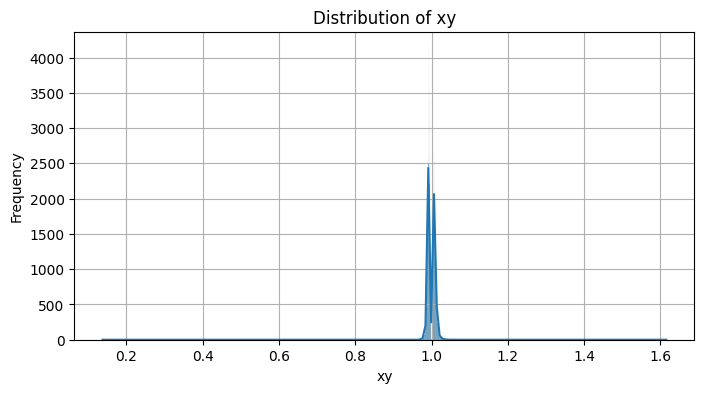

In [36]:
plot_hist_numeric(X_fich, 'xy')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000176 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1295
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 26
[LightGBM] [Info] Start training from score 3926.531459
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1296
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 26
[LightGBM] [Info] Start training from score 3944.897997
[LightGBM] [Warning] F

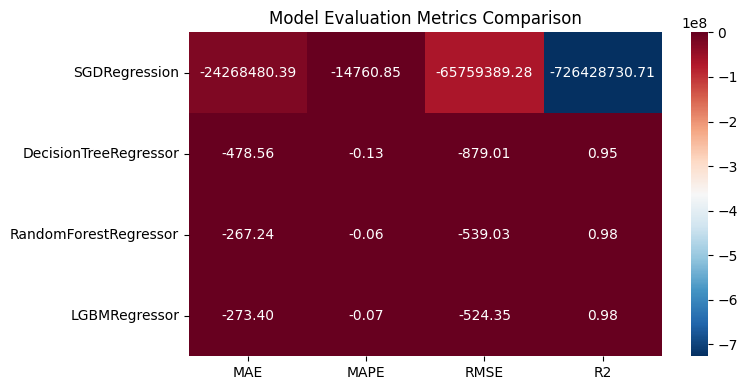

In [37]:
fich_metrics = train_evaluate_models_cv_reg(
    models=models,
    X=X_fich,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                                 MAE          MAPE          RMSE            R2
 SGDRegression          3.310456e+07  23300.617233  5.759402e+07  8.793381e+08
 DecisionTreeRegressor  6.402653e+00      0.004092  8.932893e+00  9.804289e-04
 RandomForestRegressor  2.522785e+00      0.003942  5.409401e+00  3.718560e-04
 LGBMRegressor          1.409125e+01      0.010016  1.956111e+01  1.314920e-03)

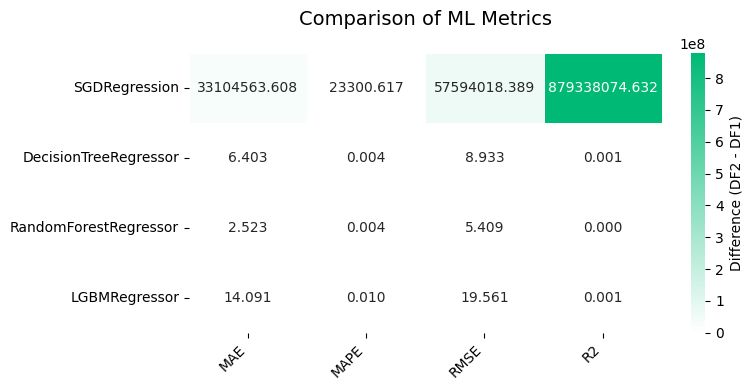

In [38]:
compare_metrics_heatmap(initial_metrics, fich_metrics)

Получили небольшие приросты ко всем моделям